Assignment 5

Objective: To research the implementation of convolutional neural networks to do object detection/segmentation/classification

For this assignment, you will need to do the following:
1.	Identify a domain for this research assignment.
2.	Identify the research focus, i.e., object detection, segmentation, or classification.
3.	Either construct a training data set from scratch or use the existing data set from sources like GitHub, Kaggle, or online repository.
4.	Research a technique to train a convolutional neural network on the data set you identified in step 3.
5.	Test your trained model with a new unseen data and report the output of your model.

# Initialization

Establish file paths from ourfile structure.

In [236]:
import os
# Define directory paths
dataset = "dataset_2500"
dataset_dir = os.path.join(os.getcwd(), dataset)
datasplits_dir = os.path.join(dataset_dir, "datasplits")
images_dir = os.path.join(dataset_dir, "images")
labels_dir = os.path.join(dataset_dir, "labels")
metadata_dir = os.path.join(dataset_dir, "metadata")
model_dir = os.path.join(dataset_dir, "model")
# Define file paths
classes_file = os.path.join(metadata_dir, "classes.txt")
train_file = os.path.join(datasplits_dir, "train.txt")
val_file = os.path.join(datasplits_dir, "val.txt")
test_file = os.path.join(datasplits_dir, "test.txt")

Verify file paths.

In [237]:
print(f"Dataset directory: {dataset_dir}")
print(f"Datasplits directory: {datasplits_dir}")
print(f"Images directory: {images_dir}")
print(f"Labels directory: {labels_dir}")
print(f"Metadata directory: {metadata_dir}")
print(f"Model directory: {model_dir}")
print(f"Classes file: {classes_file}")
print(f"Train split file: {train_file}")
print(f"Validation split file: {val_file}")
print(f"Test split file: {test_file}")

Dataset directory: <PROJECT_ROOT>\dataset_2500
Datasplits directory: <PROJECT_ROOT>\dataset_2500\datasplits
Images directory: <PROJECT_ROOT>\dataset_2500\images
Labels directory: <PROJECT_ROOT>\dataset_2500\labels
Metadata directory: <PROJECT_ROOT>\dataset_2500\metadata
Model directory: <PROJECT_ROOT>\dataset_2500\model
Classes file: <PROJECT_ROOT>\dataset_2500\metadata\classes.txt
Train split file: <PROJECT_ROOT>\dataset_2500\datasplits\train.txt
Validation split file: <PROJECT_ROOT>\dataset_2500\datasplits\val.txt
Test split file: <PROJECT_ROOT>\dataset_2500\datasplits\test.txt


We take our .txt files and parse out the information into lists.

In [238]:
def load_class_names(classes_file):
    """Load class names from classes.txt"""
    with open(classes_file, 'r') as f:
        class_names = [line.strip() for line in f.readlines()]
    return class_names

def load_train_val_paths(train_file, test_file, val_file):
    """Load training and validation image paths"""
    with open(train_file, 'r') as f:
        train_paths = [line.strip() for line in f.readlines()]
    
    with open(val_file, 'r') as f:
        val_paths = [line.strip() for line in f.readlines()]
        
    with open(test_file, 'r') as f:
        test_paths = [line.strip() for line in f.readlines()]
    
    return train_paths, val_paths, test_paths

Load files.

In [239]:
class_names = load_class_names(classes_file)
train_paths, test_paths, val_paths = load_train_val_paths(train_file, test_file, val_file)

Define Global constant variables.

In [240]:
SAMPLE_SIZE = 2500
IMAGE_SIZE = 256
OBJECT_SIZE = 32

# Exploring Data

## Verify Data

Confirm images and labels are not empty and that there are an equal number for each

In [241]:
# Get filenames without extensions
image_files = [os.path.splitext(f)[0] for f in os.listdir(images_dir) if f.endswith(".png")]
label_files = [os.path.splitext(f)[0] for f in os.listdir(labels_dir) if f.endswith(".txt")]

# Count totals
print(f"Total images: {len(image_files)}")
print(f"Total labels: {len(label_files)}")

# Compare sets
image_set = set(image_files)
label_set = set(label_files)

# Check for mismatches
missing_labels = image_set - label_set
missing_images = label_set - image_set

# Report mismatches
if missing_labels:
    print(f"\nImages without labels: {len(missing_labels)}")
    for name in sorted(missing_labels):
        print(f"  {name}.png")
else:
    print("\nAll images have corresponding labels.")

if missing_images:
    print(f"\nLabels without images: {len(missing_images)}")
    for name in sorted(missing_images):
        print(f"  {name}.txt")
else:
    print("All labels have corresponding images.")

Total images: 2500
Total labels: 2500

All images have corresponding labels.
All labels have corresponding images.


Verify that the labels are not empty and that the format is appropriate

In [242]:
# Dimensions of your images (fixed at 256x256)
img_width = IMAGE_SIZE
img_height = IMAGE_SIZE

invalid_coords = []
out_of_bounds = []

for filename in os.listdir(labels_dir):
    if not filename.endswith('.txt'):
        continue

    path = os.path.join(labels_dir, filename)
    with open(path, 'r') as f:
        for line_num, line in enumerate(f, 1):
            parts = line.strip().split()
            if len(parts) != 5:
                invalid_coords.append((filename, line_num, line))
                continue

            class_id, x_center, y_center, width, height = map(float, parts)

            if not all(0 <= val <= 1 for val in [x_center, y_center, width, height]):
                invalid_coords.append((filename, line_num, line))
                continue

            x_min = x_center - width / 2
            x_max = x_center + width / 2
            y_min = y_center - height / 2
            y_max = y_center + height / 2

            if not (0 <= x_min <= 1 and 0 <= x_max <= 1 and
                    0 <= y_min <= 1 and 0 <= y_max <= 1):
                out_of_bounds.append((filename, line_num, line))

print(f"Total label files checked: {len(os.listdir(labels_dir))}")
print(f"Invalid (non-normalized or malformed) labels: {len(invalid_coords)}")
print(f"Out-of-bounds boxes: {len(out_of_bounds)}")

if invalid_coords:
    print("\nExamples of invalid coordinates:")
    for item in invalid_coords[:5]:
        print(item)

if out_of_bounds:
    print("\nExamples of out-of-bounds boxes:")
    for item in out_of_bounds[:5]:
        print(item)


Total label files checked: 2500
Invalid (non-normalized or malformed) labels: 0
Out-of-bounds boxes: 0


Each sample has 2 targets and 2 distractors. We count the total number of each. We expect 2,500 x 2 = 5,000 for each.

In [243]:
# Initialize counters
target_count = 0
distractor_count = 0

# Iterate over all .txt files in the labels directory
for label_file in os.listdir(labels_dir):
    if label_file.endswith(".txt"):
        label_path = os.path.join(labels_dir, label_file)
        with open(label_path, 'r') as f:
            for line in f:
                class_id = line.strip().split()[0]
                if class_id == '0':
                    target_count += 1
                elif class_id == '1':
                    distractor_count += 1

# Print results
print(f"Total targets: {target_count}")
print(f"Total distractors: {distractor_count}")

# Avoid divide-by-zero
if distractor_count != 0:
    print(f"Target to Distractor ratio: {target_count / distractor_count:.2f}")
else:
    print("Target to Distractor ratio: undefined (no distractors)")

Total targets: 5000
Total distractors: 5000
Target to Distractor ratio: 1.00


## Preview Data

View samples from each file in the file structure to confirm they are not empty and that the content is well-formed

In [244]:
def preview_file(filepath, num_lines=3):
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i + 1 == num_lines:
                break

In [245]:
preview_file(classes_file)

target
distractor


In [246]:
preview_file(train_file)

dataset_2500/images/sample_00433.png
dataset_2500/images/sample_02356.png
dataset_2500/images/sample_01031.png


In [247]:
preview_file(val_file)

dataset_2500/images/sample_00467.png
dataset_2500/images/sample_02196.png
dataset_2500/images/sample_00116.png


In [248]:
preview_file(test_file)

dataset_2500/images/sample_00150.png
dataset_2500/images/sample_00995.png
dataset_2500/images/sample_00674.png


Using the information from the labels, we draw the bounding boxes and label our targets and distractors for select samples.

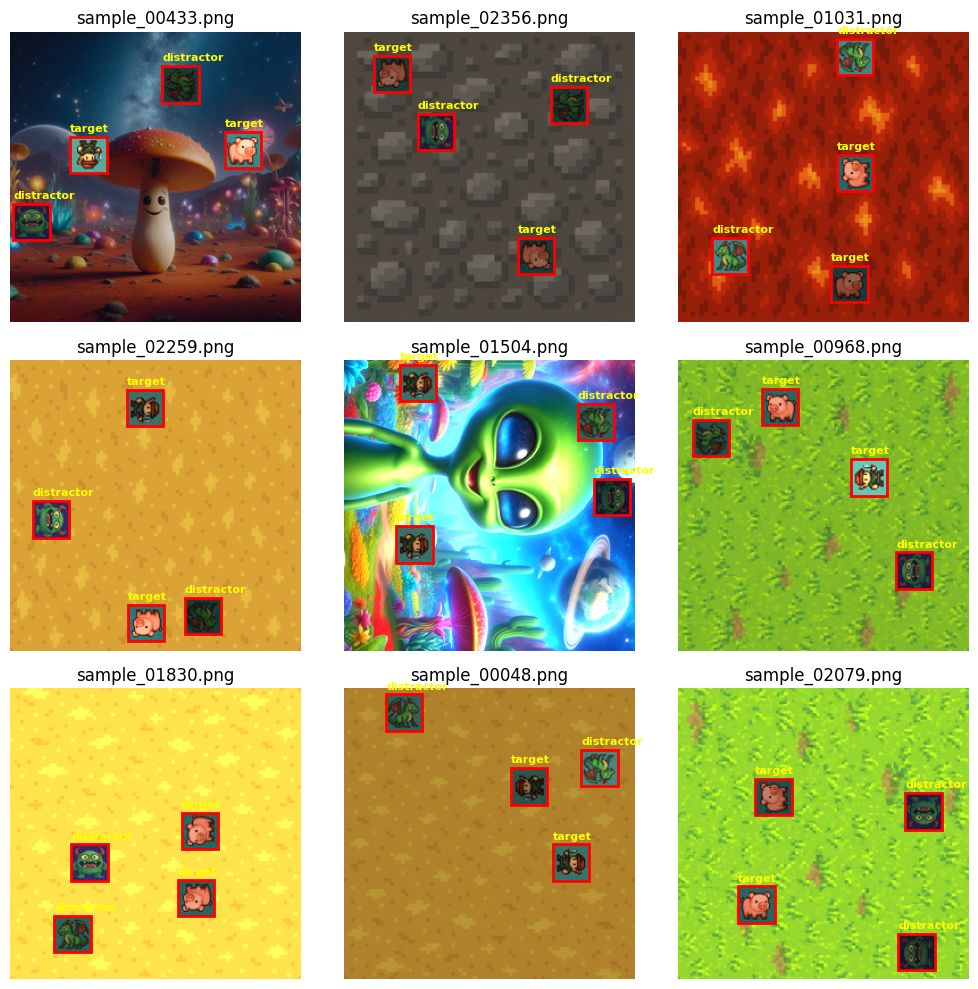

In [249]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import math

# Load sample image paths
num_samples = 9  # adjust as needed
sample_paths = train_paths[:num_samples]

# Grid setup
grid_cols = 3
grid_rows = math.ceil(num_samples / grid_cols)
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(10, 10))
axes = axes.flatten()  # so we can index them as a 1D list

# Loop through selected samples
for idx, img_path in enumerate(sample_paths):
    ax = axes[idx]
    img = Image.open(img_path)
    img_width, img_height = img.size

    # Get label file
    image_filename = os.path.basename(img_path)
    label_filename = os.path.splitext(image_filename)[0] + ".txt"
    label_path = os.path.join(labels_dir, label_filename)

    ax.imshow(img)

    # Draw boxes
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:])
                
                # Convert normalized YOLO to pixel coords
                x_center *= img_width
                y_center *= img_height
                width *= img_width
                height *= img_height
                x1 = (x_center - width / 2) - 0.5
                y1 = (y_center - height / 2) - 1

                rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1 - 5, class_names[class_id], color='yellow', fontsize=8, weight='bold')

    ax.set_title(image_filename)
    ax.axis('off')

# Hide unused subplots (if num_samples < grid size)
for i in range(num_samples, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# Preprocessing

Normalize and convert our sample image to a tensor. We capture the image file name and use that to load the corresponding label of the same name. We use the information in the label to get the following information: class id, center x, center y, width, and height. The boxes are then converted to tensor. 

In [250]:
import tensorflow as tf
import numpy as np

def load_image_and_labels(image_path, labels_dir, image_size=(IMAGE_SIZE, IMAGE_SIZE)):
    # Load and normalize image
    img = Image.open(image_path).convert('RGB')
    img = img.resize(image_size)
    img = np.asarray(img) / 255.0  # normalize
    img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)

    filename = os.path.basename(image_path)
    label_file = os.path.splitext(filename)[0] + ".txt"
    label_path = os.path.join(labels_dir, label_file)

    boxes = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id, cx, cy, w, h = map(float, parts)
                    boxes.append([class_id, cx, cy, w, h])
    
    boxes_tensor = tf.convert_to_tensor(boxes, dtype=tf.float32)
    return img_tensor, boxes_tensor, label_file


Verify that our function works and that the object and label have been properly joined.

In [251]:
test_image_path = train_paths[4]
image_tensor, boxes_tensor, label_file = load_image_and_labels(test_image_path, labels_dir)

print(f"Image: {test_image_path}")
print(f"Image shape: {image_tensor.shape}")
print()
print(f"Label: {label_file}")
print("Bounding boxes:")
print(boxes_tensor.numpy())

Image: dataset_2500/images/sample_01504.png
Image shape: (256, 256, 3)

Label: sample_01504.txt
Bounding boxes:
[[0.       0.253906 0.082031 0.125    0.125   ]
 [0.       0.242188 0.636719 0.125    0.125   ]
 [1.       0.867188 0.214844 0.125    0.125   ]
 [1.       0.921875 0.472656 0.125    0.125   ]]


Take our raw labels and convert them to a workable format for our yolo-style model.

In [252]:
def format_yolo_labels(yolo_boxes, S=16, A=1, anchors=[(OBJECT_SIZE, OBJECT_SIZE)]):
    label_grid = np.zeros((S, S, A, 6), dtype=np.float32)

    for i, box in enumerate(yolo_boxes):
        class_id, cx, cy, w, h = box
        grid_x = int(cx * S)
        grid_y = int(cy * S)

        grid_x = min(grid_x, S - 1)
        grid_y = min(grid_y, S - 1)

        anchor = i % A
        anchor_w, anchor_h = anchors[anchor]

        rel_cx = cx * S - grid_x
        rel_cy = cy * S - grid_y

        rel_w = w / (anchor_w / IMAGE_SIZE)   
        rel_h = h / (anchor_h / IMAGE_SIZE)

        # Flip class target to be used with Sigmoid functions
        class_id = 1.0 if class_id == 0 else 0.0  # now target=1, distractor=0

        label_grid[grid_y, grid_x, anchor, 0] = class_id

        label_grid[grid_y, grid_x, anchor, 1:3] = [rel_cx, rel_cy]
        label_grid[grid_y, grid_x, anchor, 3:5] = [rel_w, rel_h]
        label_grid[grid_y, grid_x, anchor, 5] = 1.0

    return label_grid


Load our images in tensor format and our labels in the yolo format.

In [253]:
def tf_load_image_and_labels(image_path):
    image_path = image_path.numpy().decode()
    img_tensor, boxes_tensor, _ = load_image_and_labels(image_path, labels_dir)

    boxes_np = boxes_tensor.numpy()
    anchors = [(OBJECT_SIZE, OBJECT_SIZE)]
    grid_labels = format_yolo_labels(boxes_np, S=16, A=1, anchors=anchors)

    return img_tensor, grid_labels


This function wraps our Python function so it can be used within TensorFlow’s data pipeline.

In [254]:
def load_wrapper(image_path):
    image, label_grid = tf.py_function(func=tf_load_image_and_labels,
                                       inp=[image_path],
                                       Tout=(tf.float32, tf.float32))
    image.set_shape((IMAGE_SIZE, IMAGE_SIZE, 3))
    label_grid.set_shape((16, 16, 1, 6))
    return image, label_grid


Create our training set in tensor format.

In [255]:
# Convert your list of image paths to a Tensor
train_paths_tensor = tf.convert_to_tensor(train_paths, dtype=tf.string)

# Build the dataset
train_dataset = tf.data.Dataset.from_tensor_slices(train_paths_tensor)
train_dataset = train_dataset.map(load_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=100)
train_dataset = train_dataset.batch(4)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)


Inspect a sample contained in our updated training set to verify proper sample types in training set.

In [256]:
# Inspect one sample from the dataset
image, label = next(iter(train_dataset.take(1)))

# Find anchor positions where object is present
nonzero = tf.where(label[0, ..., 5] == 1.0)

print("Active anchor boxes:", nonzero.numpy())
print("Corresponding w/h:", tf.gather_nd(label[0, ..., 3:5], nonzero).numpy())


Active anchor boxes: [[ 2  4  0]
 [ 6  2  0]
 [ 7  8  0]
 [ 8 13  0]]
Corresponding w/h: [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]


# Model

## Implementation

This is a YOLO-based model. It was chosen for it's fast and lightweight design and capabilities with object detection. The model contains 4 convolutional layers for feature extraction, each followed by max pooling, and a final 1×1 convolution layer that predicts bounding box parameters and class scores. The output includes bounding box centers (sigmoid), sizes (exponential scaling), objectness scores, and binary class probabilities.


In [257]:
from tensorflow.keras import layers, models # type: ignore

def build_model(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), S=16, A=1):
    inputs = layers.Input(shape=input_shape)

    # Backbone
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)  # Output shape: (S, S, channels)

    # Detection head: (S, S, A * 6)
    out_channels = A * 6
    x = layers.Conv2D(out_channels, 1, padding='same')(x)

    # Reshape to (S, S, A, 6)
    x = layers.Reshape((S, S, A, 6))(x)

    # Now wrap each activation inside a Lambda layer
    cxcy = layers.Lambda(lambda t: tf.sigmoid(t[..., 0:2]))(x)  # center
    wh = layers.Lambda(lambda t: tf.exp(t[..., 2:4]))(x)
    obj  = layers.Lambda(lambda t: tf.sigmoid(t[..., 4:5]))(x)  # objectness
    cls  = layers.Lambda(lambda t: tf.sigmoid(t[..., 5:6]))(x)  # class prob

    output = layers.Concatenate(axis=-1)([cxcy, wh, obj, cls])

    model = models.Model(inputs=inputs, outputs=output)
    return model


In [258]:
model = build_model()
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 128, 128,  │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 64, 64,    │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_21… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 32, 32,    │          0 │ conv2d_27[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_22… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_23    │ (None, 16, 16,    │          0 │ conv2d_28[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 16, 16, 6) │      1,542 │ max_pooling2d_23… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 16, 16, 1, │          0 │ conv2d_29[0][0]   │
│                     │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_20 (Lambda)  │ (None, 16, 16, 1, │          0 │ reshape_5[0][0]   │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_21 (Lambda)  │ (None, 16, 16, 1, │          0 │ reshape_5[0][0]   │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_22 (Lambda)  │ (None, 16, 16, 1, │          0 │ reshape_5[0][0]   │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_23 (Lambda)  │ (None, 16, 16, 1, │          0 │ reshape_5[0][0]   │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 16, 16, 1, │          0 │ lambda_20[0][0],  │
│ (Concatenate)       │ 6)                │            │ lambda_21[0][0],  │
│                     │                   │            │ lambda_22[0][0],  │
│                     │                   │            │ lambda_23[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 389,958 (1.49 MB)

 Trainable params: 389,958 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

Focal loss is a variant of binary cross-entropy that down-weights easy examples and focuses learning on hard, misclassified cases.

In [259]:
def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
    modulating_factor = tf.pow(1.0 - p_t, gamma)
    return alpha_factor * modulating_factor * bce

Calculates the total loss for a YOLO-style object detection model by combining three components: localization loss (bounding box accuracy), objectness loss (confidence in object presence), and classification loss (target vs. distractor). YOLO-style models tend to work best with a grid type loss function. Localization and classification losses are applied only to cells containing objects, while objectness loss is applied to both object and background cells. The loss is normalized by the number of objects in the image to ensure stable training.


In [260]:
def grid_loss(y_true, y_pred):

    # Predicted components
    pred_cxcy = y_pred[..., 0:2]  
    pred_wh   = y_pred[..., 2:4]  
    pred_obj  = y_pred[..., 4]    
    pred_cls  = y_pred[..., 5]    

    # Ground truth components
    true_cls  = y_true[..., 0]    # 1.0 = target, 0.0 = distractor
    true_cxcy = y_true[..., 1:3]
    true_wh   = y_true[..., 3:5]
    true_obj  = y_true[..., 5]    # 1.0 = real object

    # --- Masks ---
    obj_mask = tf.cast(true_obj > 0.5, tf.float32)      
    noobj_mask = 1.0 - obj_mask                         

    # --- Localization loss (only for objects) ---
    loc_loss = tf.reduce_sum(obj_mask[..., None] * tf.square(true_cxcy - pred_cxcy))
    loc_loss += tf.reduce_sum(obj_mask[..., None] * tf.square(true_wh - pred_wh))

    # --- Objectness loss ---
    bce_obj = tf.keras.backend.binary_crossentropy(true_obj, pred_obj)
    obj_loss = tf.reduce_sum(obj_mask * bce_obj) + tf.reduce_sum(noobj_mask * bce_obj)

    # --- Classification loss (for all objects) ---
    cls_focal = focal_loss(true_cls, pred_cls, alpha=0.25, gamma=1.0)
    cls_loss = tf.reduce_sum(obj_mask * cls_focal)

    # --- Normalize by number of objects ---
    norm = tf.reduce_sum(obj_mask) + 1e-6
    total_loss = (loc_loss + obj_loss + cls_loss) / norm

    return total_loss

Compile our model using Adam() as an optimizer and our defined loss function.

In [261]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=grid_loss
)

## Training

Similar to training set, we prepare our validation set. This will be used in conjunction with training to train our model.

In [262]:
# Convert list to tensor
val_paths_tensor = tf.convert_to_tensor(val_paths, dtype=tf.string)

# Build validation dataset
val_dataset = tf.data.Dataset.from_tensor_slices(val_paths_tensor)
val_dataset = val_dataset.map(load_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(4)  # No shuffle for validation
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

Implement early stopping to reduce the chance of overfitting. We will evaluate val_loss and allow 5 consecutive non-improving steps before early stopping. The best weight will be kept.

In [263]:
from tensorflow.keras.callbacks import EarlyStopping   # type: ignore

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',               
    patience=5,                   
    restore_best_weights=True     
)

Train our model on our training dataset. We use our validation set to assess val_loss for each epoch. This will be running 20 epochs and employ early stop when necessary. We will print a line for each epoch through verbose.

In [264]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 5.5426 - val_loss: 0.3918
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - loss: 0.2489 - val_loss: 0.1163
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - loss: 0.0929 - val_loss: 0.0807
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - loss: 0.0711 - val_loss: 0.0499
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - loss: 0.0400 - val_loss: 0.0489
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - loss: 0.0340 - val_loss: 0.0466
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - loss: 0.0260 - val_loss: 0.0359
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - loss: 0.0523 - val_loss: 0.0341
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - loss: 0.0311 - val_loss: 0.0293
Epoch 10/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - loss: 0.0143 - val_loss: 0.0390
Epoch 11/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - loss: 0.0061 - val_loss: 0.0188
Epoch 12/20
438/438 ━━━━━━━━━━

We plot training loss vs validation loss. This is a helpful visual to see if overfitting is occurring in our training.

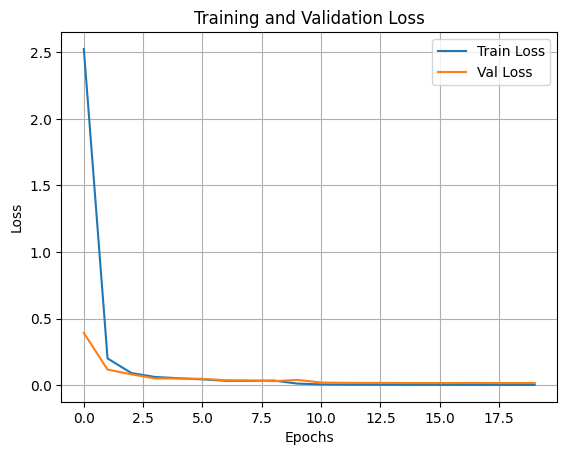

In [265]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Using our newly trained model, we can visualize some samples and verify that targets are being correctly identified and distractors are not being selected.

In [266]:
import random

def visualize_batch_predictions(model, image_paths, anchors, labels_dir, num_images=4):
    selected_paths = random.sample(image_paths, num_images)
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    for idx, img_path in enumerate(selected_paths):
        # Load image and label
        image_raw = tf.io.read_file(img_path)
        image = tf.image.decode_png(image_raw, channels=3)
        image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE)).numpy().astype(np.uint8)

        img_tensor, boxes_tensor, _ = load_image_and_labels(img_path, labels_dir)
        label_grid = format_yolo_labels(boxes_tensor.numpy(), S=16, A=1)

        # Predict
        y_pred = model.predict(tf.expand_dims(image / 255.0, 0), verbose=0)[0]

        # Draw on subplot
        ax = axes[idx // 2][idx % 2]
        ax.imshow(image)
        S, A = 16, 1
        H, W = IMAGE_SIZE, IMAGE_SIZE

        for i in range(S):
            for j in range(S):
                for a in range(A):
                    cx, cy, w, h, obj, cls_prob = y_pred[i, j, a]
                    if obj < 0.5 or cls_prob < 0.5:
                        continue
                    bx = (j + cx) * (W / S)
                    by = (i + cy) * (H / S)
                    bw = w * anchors[a][0]
                    bh = h * anchors[a][1]
                    x1 = bx - bw / 2
                    y1 = by - bh / 2
                    rect = patches.Rectangle((x1, y1), bw, bh, linewidth=2, edgecolor='lime', facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 2, f"P:{cls_prob:.2f} | O:{obj:.2f}", color='lime', fontsize=6)

        # Draw GT boxes
        for i in range(S):
            for j in range(S):
                for a in range(A):
                    class_id, cx, cy, w, h, obj = label_grid[i, j, a]
                    if obj < 0.5:
                        continue
                    bx = (j + cx) * (W / S)
                    by = (i + cy) * (H / S)
                    bw = w * anchors[a][0]
                    bh = h * anchors[a][1]
                    x1 = bx - bw / 2
                    y1 = by - bh / 2
                    color = 'red' if class_id == 1 else 'blue'
                    label = 'Target' if class_id == 1 else 'Distractor'
                    rect = patches.Rectangle((x1, y1), bw, bh, linewidth=1.5, edgecolor=color, facecolor='none', linestyle='dashed')
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 2, label, color=color, fontsize=6)

        ax.axis('off')
        ax.set_title(os.path.basename(img_path))

    plt.tight_layout()
    plt.show()


The call for the above method.

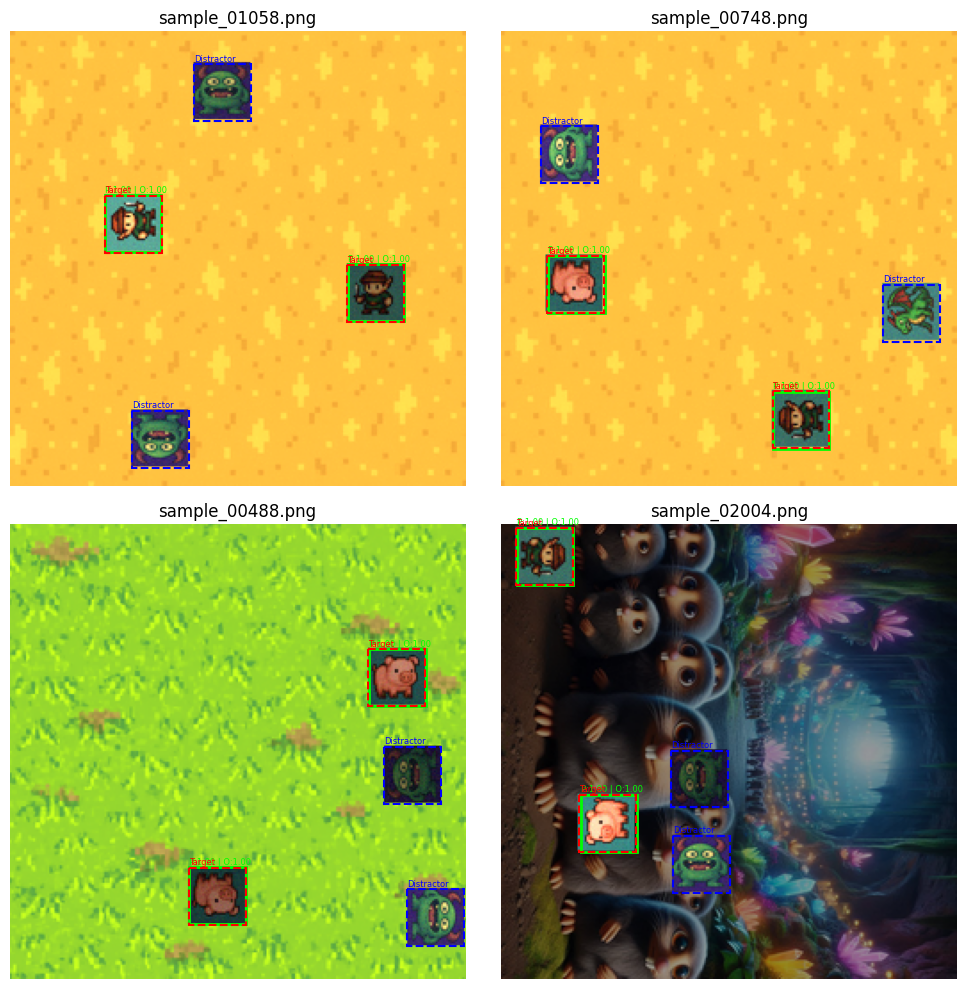

In [267]:
visualize_batch_predictions(
    model=model,
    image_paths=val_paths,       
    anchors=[(OBJECT_SIZE, OBJECT_SIZE)],
    labels_dir=labels_dir,
    num_images=4
)

# Fine Tuning

The IoU (Intersection over Union) matrix measures how much each predicted bounding box overlaps with each ground truth box. A score of 1.00 indicates perfect matching. It is used to determine matches, compute true/false positives, and evaluate detection performance using metrics like precision, recall, and mAP.

In [268]:
def compute_iou_matrix(pred_boxes, true_boxes):
    pred_boxes = tf.expand_dims(pred_boxes, 1)
    true_boxes = tf.expand_dims(true_boxes, 0)

    inter_x1 = tf.maximum(pred_boxes[..., 0], true_boxes[..., 0])
    inter_y1 = tf.maximum(pred_boxes[..., 1], true_boxes[..., 1])
    inter_x2 = tf.minimum(pred_boxes[..., 2], true_boxes[..., 2])
    inter_y2 = tf.minimum(pred_boxes[..., 3], true_boxes[..., 3])

    inter_area = tf.maximum(inter_x2 - inter_x1, 0) * tf.maximum(inter_y2 - inter_y1, 0)
    pred_area = (pred_boxes[..., 2] - pred_boxes[..., 0]) * (pred_boxes[..., 3] - pred_boxes[..., 1])
    true_area = (true_boxes[..., 2] - true_boxes[..., 0]) * (true_boxes[..., 3] - true_boxes[..., 1])
    union_area = pred_area + true_area - inter_area

    return inter_area / (union_area + 1e-6)

Helper function to extract true boxes.

In [269]:
def extract_true_boxes(true_grid):
    boxes = []
    for y in range(true_grid.shape[0]):
        for x in range(true_grid.shape[1]):
            for a in range(true_grid.shape[2]):
                if true_grid[y, x, a, 5] == 1.0:  # object mask
                    cls_id, cx, cy, w, h = true_grid[y, x, a][:5]
                    if cls_id != 1.0:  # skip distractors
                        continue
                    abs_cx = (x + cx) / true_grid.shape[1]
                    abs_cy = (y + cy) / true_grid.shape[0]
                    x1 = abs_cx - w / 2
                    y1 = abs_cy - h / 2
                    x2 = abs_cx + w / 2
                    y2 = abs_cy + h / 2
                    boxes.append([x1, y1, x2, y2])
    return boxes

NMS stands for non-maximum suppression. This is a technique that is emplyed to remove duplicate, overlapping predictions that may occur and are common in YOLO-style models. This function will provide evaluation of true positives, false positives, false negatives and IoUs while applying NMS. True negatives are not determined because our focus is the objects in the image, and "everything else" is too ambiguous and not helpful. The output metrics include the TP, FP, FN, Precision, Recall, and mean IoU. 

```
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)
Mean IoU = (SUM IoU matched boxes) / TP
```

In [270]:
def evaluate_predictions_with_nms(model, dataset, iou_threshold=0.5, score_threshold=0.01, nms_iou=0.5):
    TP, FP, FN = 0, 0, 0
    all_ious = []

    for images, true_grids in dataset:
        preds = model(images, training=False)
        batch_size = images.shape[0]

        for i in range(batch_size):
            pred = preds[i].numpy()
            true = true_grids[i].numpy()

            # Extract predictions
            boxes = []
            scores = []
            for y in range(pred.shape[0]):
                for x in range(pred.shape[1]):
                    for a in range(pred.shape[2]):
                        cx, cy, w, h, obj_conf, cls_conf = pred[y, x, a]
                        score = obj_conf * cls_conf
                        if score > score_threshold:
                            abs_cx = (x + cx) / pred.shape[1]
                            abs_cy = (y + cy) / pred.shape[0]
                            x1 = abs_cx - w / 2
                            y1 = abs_cy - h / 2
                            x2 = abs_cx + w / 2
                            y2 = abs_cy + h / 2
                            boxes.append([x1, y1, x2, y2])
                            scores.append(score)

            if not boxes:
                true_boxes = extract_true_boxes(true)
                FN += len(true_boxes)
                continue

            boxes = tf.convert_to_tensor(boxes, dtype=tf.float32)
            scores = tf.convert_to_tensor(scores, dtype=tf.float32)

            selected_indices = tf.image.non_max_suppression(
                boxes=boxes,
                scores=scores,
                max_output_size=20,
                iou_threshold=tf.cast(nms_iou, tf.float32),
                score_threshold=tf.cast(score_threshold, tf.float32)
            )

            boxes = tf.gather(boxes, selected_indices)
            scores = tf.gather(scores, selected_indices)

            pred_boxes = boxes

            # Ground truth boxes
            true_boxes = extract_true_boxes(true)

            if len(true_boxes) == 0:
                FP += len(pred_boxes)
                continue

            true_boxes = tf.convert_to_tensor(true_boxes, dtype=tf.float32)

            ious = compute_iou_matrix(pred_boxes, true_boxes)
            max_iou_per_pred = tf.reduce_max(ious, axis=1)
            max_iou_per_true = tf.reduce_max(ious, axis=0)

            for iou in max_iou_per_pred:
                if iou >= iou_threshold:
                    TP += 1
                    all_ious.append(iou.numpy())
                else:
                    FP += 1

            FN += tf.reduce_sum(tf.cast(max_iou_per_true < iou_threshold, tf.int32)).numpy()

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    mean_iou = np.mean(all_ious) if all_ious else 0.0

    return {
        "TP": TP, "FP": FP, "FN": FN,
        "Precision": precision,
        "Recall": recall,
        "Mean IoU": mean_iou
    }


This calculates the Average Precision (AP) using true positive flags and model confidence scores. It summarizes precision-recall performance across thresholds and is commonly used to compute AP@0.5 in object detection tasks.


In [271]:
from sklearn.metrics import average_precision_score

def compute_ap(y_true_all, y_scores_all):
    if len(y_true_all) == 0:
        return 0.0
    return average_precision_score(y_true_all, y_scores_all)

Similar to evaluate_predictions_with_nms, we will also evaluate with AP.

In [272]:
# Accumulate all ground-truth and prediction matches across dataset
def evaluate_with_ap(model, dataset, iou_threshold=0.5, score_thresholds=np.linspace(0.01, 0.9, 20)):
    y_true_all = []
    y_scores_all = []
    
    for images, true_grids in dataset:
        preds = model(images, training=False)

        batch_size = images.shape[0]
        for i in range(batch_size):
            pred = preds[i].numpy()
            true = true_grids[i].numpy()

            true_boxes = []
            for y in range(true.shape[0]):
                for x in range(true.shape[1]):
                    for a in range(true.shape[2]):
                        if true[y, x, a, 5] == 1.0:
                            cls_id, cx, cy, w, h = true[y, x, a][:5]
                            abs_cx = (x + cx) / true.shape[1]
                            abs_cy = (y + cy) / true.shape[0]
                            x1 = abs_cx - w / 2
                            y1 = abs_cy - h / 2
                            x2 = abs_cx + w / 2
                            y2 = abs_cy + h / 2
                            true_boxes.append([x1, y1, x2, y2])
            
            pred_boxes = []
            scores = []
            for y in range(pred.shape[0]):
                for x in range(pred.shape[1]):
                    for a in range(pred.shape[2]):
                        cx, cy, w, h, obj_conf, cls_conf = pred[y, x, a]
                        score = obj_conf * cls_conf
                        abs_cx = (x + cx) / pred.shape[1]
                        abs_cy = (y + cy) / pred.shape[0]
                        x1 = abs_cx - w / 2
                        y1 = abs_cy - h / 2
                        x2 = abs_cx + w / 2
                        y2 = abs_cy + h / 2
                        pred_boxes.append([x1, y1, x2, y2])
                        scores.append(score)
            
            pred_boxes = tf.convert_to_tensor(pred_boxes, dtype=tf.float32)
            scores = tf.convert_to_tensor(scores, dtype=tf.float32)

            if len(true_boxes) == 0:
                continue

            true_boxes = tf.convert_to_tensor(true_boxes, dtype=tf.float32)
            ious = compute_iou_matrix(pred_boxes, true_boxes)

            max_ious = tf.reduce_max(ious, axis=1).numpy()

            for i, iou in enumerate(max_ious):
                y_scores_all.append(scores[i].numpy())
                y_true_all.append(1 if iou >= iou_threshold else 0)

    ap50 = compute_ap(np.array(y_true_all), np.array(y_scores_all))
    return ap50, y_true_all, y_scores_all


Now we train our model utilizing a tuner to evaluate which hyperparameter values will provide optimal results.

```
conf_thresh = confidence level for predictions
nms_thresh = threshold for removal of duplicates
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)
F1 = (Precission * Recall) / (Precision + Recall); balanced score between precision and recall
Mean IoU = (SUM IoU matched boxes) / TP
```

In [273]:
def tune_nms_and_thresholds(model, dataset, 
                            score_thresholds=np.linspace(0.01, 0.5, 10),
                            nms_thresholds=np.linspace(0.3, 0.7, 5)):
    results = []

    for score_thresh in score_thresholds:
        for nms_iou in nms_thresholds:
            metrics = evaluate_predictions_with_nms(
                model,
                dataset,
                score_threshold=float(score_thresh),  # to ensure native float
                nms_iou=float(nms_iou),
                iou_threshold=0.5
            )

            results.append({
                "conf_thresh": score_thresh,
                "nms_thresh": nms_iou,
                "precision": metrics["Precision"],
                "recall": metrics["Recall"],
                "f1": 2 * metrics["Precision"] * metrics["Recall"] / (metrics["Precision"] + metrics["Recall"] + 1e-6),
                "mean_iou": metrics["Mean IoU"]
            })

    return results


Goes through all possible confidence thresholds and computes the F1 score at each one using the precision-recall curve. It returns the threshold that maximizes the F1 score, helping to tune the model's confidence cutoff for optimal performance. It plots the F1 score curve.

In [274]:
from sklearn.metrics import precision_recall_curve

def find_best_f1_threshold(y_true, y_scores, plot=False):
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    if plot:
        plt.figure(figsize=(8, 6))
        plt.plot(thresholds, f1_scores[:-1], label="F1 Score")
        plt.axvline(x=best_thresh, color='red', linestyle='--', label=f'Best Thresh: {best_thresh:.4f}')
        plt.title("F1 Score vs. Confidence Threshold")
        plt.xlabel("Confidence Threshold")
        plt.ylabel("F1 Score")
        plt.legend()
        plt.grid()
        plt.show()

    return best_thresh, best_f1

This code plots the Precision-Recall curve. 

In [275]:
def plot_pr_curve(y_true, y_scores, title="PR Curve"):
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    ap = average_precision_score(y_true, y_scores)

    plt.figure(figsize=(6, 6))
    plt.plot(recall, precision, label=f"AP@0.5 = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

Here we condense all of the evaluation code we have defined into a single method call.

In [276]:
import pandas as pd

def evaluate_model(model, dataset, iou_thresh=0.5, score_thresholds=np.linspace(0.01, 0.5, 10),
                   nms_thresholds=np.linspace(0.3, 0.7, 5), plot_pr=True, plot_f1=True):
    # Step 1: Evaluate for PR Curve and AP@0.5
    ap50, y_true_all, y_scores_all = evaluate_with_ap(model, dataset, iou_thresh)

    # Step 2: Find best threshold via F1 score
    best_thresh, best_f1 = find_best_f1_threshold(y_true_all, y_scores_all, plot=plot_f1)

    # Step 3: Evaluate combinations of NMS/conf thresholds
    results = tune_nms_and_thresholds(model, dataset, score_thresholds, nms_thresholds)
    df = pd.DataFrame(results)
    best_row = df.loc[df['f1'].idxmax()]

    # Step 4: Optionally plot PR curve
    if plot_pr:
        plot_pr_curve(y_true_all, y_scores_all, title="PR Curve (IoU ≥ 0.5)")

    return {
        "AP50": ap50,
        "Best F1": float(best_row.f1),
        "F1 from PR curve": float(best_f1),
        "Best Confidence Threshold": float(best_row.conf_thresh),
        "Best NMS IoU": float(best_row.nms_thresh),
        "Precision": float(best_row.precision),
        "Recall": float(best_row.recall),
        "Mean IoU": float(best_row.mean_iou),
    }


Apply our evaluate_model utilizing our model and validation set. These results will help determine model effectiveness and the best settings for our hyperparameters.

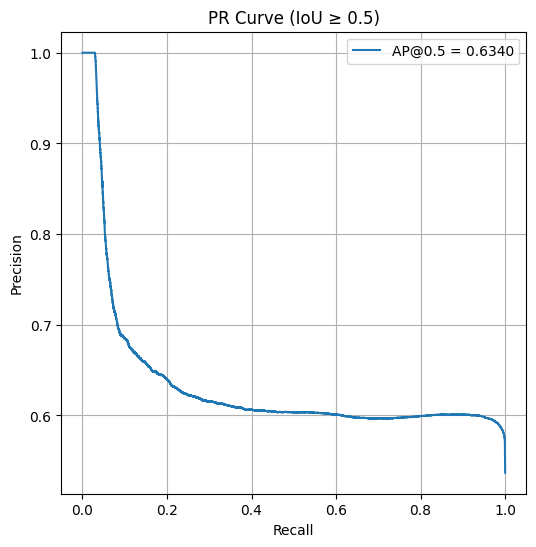

AP50: 0.6340
Best F1: 1.0000
F1 from PR curve: 0.7384
Best Confidence Threshold: 0.0644
Best NMS IoU: 0.7000
Precision: 1.0000
Recall: 1.0000
Mean IoU: 0.9778


In [277]:
results = evaluate_model(model, val_dataset, plot_pr=True, plot_f1=False)
for k, v in results.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

# Testing

Create our test set, similar to the training and validation sets.

In [278]:
test_paths_tensor = tf.convert_to_tensor(test_paths, dtype=tf.string)

test_dataset = tf.data.Dataset.from_tensor_slices(test_paths_tensor)
test_dataset = test_dataset.map(load_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(4)  # No padding needed because you always have 4 boxes
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

Use our evaluate_prediction_with_nms with the tuned settings. We use our test dataset, which our model has not seen.

In [279]:
test_metrics = evaluate_predictions_with_nms(
    model,
    test_dataset,
    score_threshold=0.0644,
    nms_iou=0.70,
    iou_threshold=0.5
)

In [280]:
print("Test Set Metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Test Set Metrics:
TP: 750
FP: 0
FN: 0
Precision: 1.0000
Recall: 1.0000
Mean IoU: 0.9780307412147522


We see that our model has performed extremely well with training and fine tuning. We will view some samples to verify that our model is in fact detecting our objects.

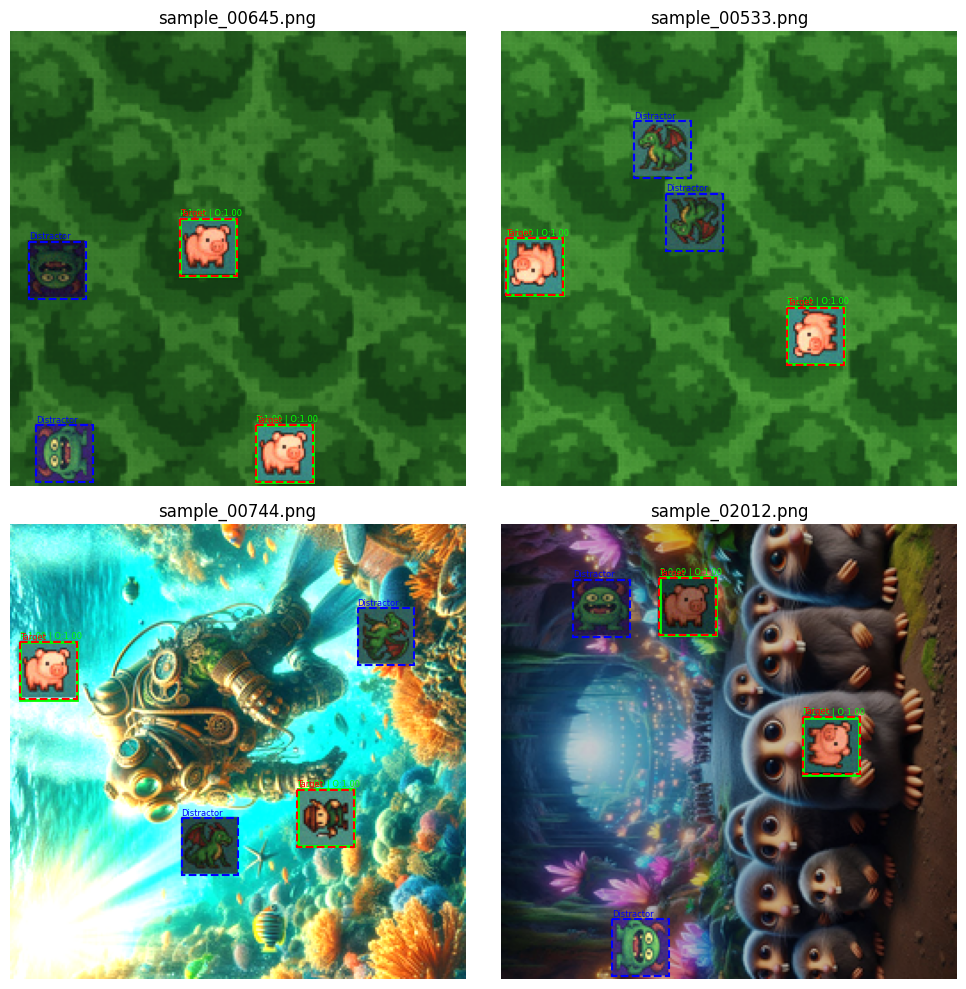

In [281]:
visualize_batch_predictions(
    model=model,
    image_paths=test_paths,
    anchors=[(OBJECT_SIZE, OBJECT_SIZE)],
    labels_dir=labels_dir,
    num_images=4
)

# Presentation

Model is saved to a designated folder path.

In [282]:
save_path = os.path.join(model_dir, "yolo_mini_model.keras")
model.save(save_path)